In [1]:
import main_program as mp
import sys
import os
internal_WSM_dir = os.getcwd()
internal_MPC_dir = os.path.abspath(os.path.join(internal_WSM_dir, '..'))
root_dir = os.path.abspath(os.path.join(internal_MPC_dir, '..'))
internal_CP_dir = os.path.abspath(os.path.join(root_dir, '6_Common_Paramaters'))
sys.path.append(internal_CP_dir)
import Common_Params as CP
import matplotlib.pyplot as plt
import pickle

c:\Users\home\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
# def plot(store_times, store_accelerations, store_velocities, store_seperations, store_detected_times, store_start_reaction_times, Dr, Vp, title):
#     fig, axes = plt.subplots(1, 3, figsize = (90, 25 * 1))                              # figsize = (width, height)
#     font = 50
#     border_thickness = 8.0
    
#     for i in range(3):
#         for spine in axes[i].spines.values():
#             spine.set_linewidth(border_thickness)  # Set border (spine) thickness
    
#     sri_1 = store_times[0].index(store_start_reaction_times)

#     axes[0].plot(store_times[0], store_seperations[0], label = f'min : {round(min(store_seperations[0]), 2)}, saturation : {round(store_seperations[0][-1], 2)}', color = 'blue', linewidth = 4)
#     axes[0].plot(store_times[0][sri_1:], [CP.Dd + CP.Td * V * 5 / 18 for V in store_velocities[0][sri_1:]], label = f'Desired final seperation : {round(CP.Dd + CP.Td * store_velocities[0][-1] * 5 / 18, 2)}', color = 'green', linewidth = 4)
#     axes[0].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
#     axes[0].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
#     axes[0].grid(True, linewidth = 4.0)
#     axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
#     axes[0].set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
#     axes[0].set_title(title, fontsize = font, fontweight = 'bold')
#     axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
#     axes[0].legend(fontsize = font)

#     axes[1].plot(store_times[0], store_velocities[0], label = f'max : {round(max(store_velocities[0]), 2)}, saturation : {round(store_velocities[0][-1], 2)}', color = 'blue', linewidth = 4)
#     axes[1].plot(store_times[0][sri_1:], [Vp * 18 / 5 for _ in range(len(store_velocities[0]))][sri_1:], label = f'Desired final velocity : {round(Vp * 18 / 5, 2)} km/hr', color = 'green', linewidth = 4)
#     axes[1].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
#     axes[1].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
#     axes[1].grid(True, linewidth = 4.0)
#     axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
#     axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
#     axes[1].set_title(title, fontsize = font, fontweight = 'bold')
#     axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
#     axes[1].legend(fontsize = font)

#     axes[2].plot(store_times[0], store_accelerations[0], label = f'min : {round(min(store_accelerations[0]), 2)}, max : {round(max(store_accelerations[0]), 2)}', color = 'blue', linewidth = 4)
#     axes[2].axvline(x = store_detected_times, color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
#     axes[2].axvline(x = store_start_reaction_times, color = 'red', linestyle = '--', label = 'Vehicle responds', linewidth = 4)
#     axes[2].grid(True, linewidth = 4.0)
#     axes[2].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
#     axes[2].set_ylabel('Acceleration [m/s^2]', fontsize = font, fontweight = 'bold')
#     axes[2].set_title(title, fontsize = font, fontweight = 'bold')
#     axes[2].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
#     axes[2].legend(fontsize = font)

#     plt.show()

In [3]:
def plot(store_times, store_accelerations, store_velocities, store_seperations, store_detected_times, store_start_reaction_times, Dr, Vp, title):
    fig, axes = plt.subplots(1, 3, figsize=(90, 25))
    font = 50
    border_thickness = 8.0

    for i in range(3):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)

    sri_1 = store_times[0].index(store_start_reaction_times)

    # Separation plot
    times = store_times[0]
    sep = store_seperations[0]
    axes[0].plot(times, sep, color='blue', label='Actual separation', linewidth=4)
    desired_sep = [CP.Dd + CP.Td * V * 5 / 18 for V in store_velocities[0][sri_1:]]
    axes[0].plot(times[sri_1:], desired_sep, label='Desired final separation', color='green', linewidth=4)
    axes[0].axvline(x=store_detected_times, color='black', linestyle='--', label='Obstacle detected', linewidth=4)
    axes[0].axvline(x=store_start_reaction_times, color='red', linestyle='--', label='Vehicle responds', linewidth=4)
    axes[0].grid(True, linewidth=4.0)
    axes[0].set_xlabel('Time [s]', fontsize=font, fontweight='bold')
    axes[0].set_ylabel('Separation [m]', fontsize=font, fontweight='bold')
    axes[0].set_title(title, fontsize=font, fontweight='bold')
    axes[0].tick_params(axis='both', which='major', labelsize=font, width=2)
    axes[0].legend(fontsize=font)

    # Velocity plot
    vel = store_velocities[0]
    axes[1].plot(times, vel, color='blue', label='Actual velocity', linewidth=4)
    desired_vel = [Vp * 18 / 5 for _ in range(len(vel))]
    axes[1].plot(times[sri_1:], desired_vel[sri_1:], label='Desired final velocity', color='green', linewidth=4)
    axes[1].axvline(x=store_detected_times, color='black', linestyle='--', label='Obstacle detected', linewidth=4)
    axes[1].axvline(x=store_start_reaction_times, color='red', linestyle='--', label='Vehicle responds', linewidth=4)
    axes[1].grid(True, linewidth=4.0)
    axes[1].set_xlabel('Time [s]', fontsize=font, fontweight='bold')
    axes[1].set_ylabel('Velocity [km/h]', fontsize=font, fontweight='bold')
    axes[1].set_title(title, fontsize=font, fontweight='bold')
    axes[1].tick_params(axis='both', which='major', labelsize=font, width=2)
    axes[1].legend(fontsize=font)

    # Acceleration plot
    acc = store_accelerations[0]
    axes[2].plot(times, acc, color='blue', label='Actual acceleration', linewidth=4)
    axes[2].axvline(x=store_detected_times, color='black', linestyle='--', label='Obstacle detected', linewidth=4)
    axes[2].axvline(x=store_start_reaction_times, color='red', linestyle='--', label='Vehicle responds', linewidth=4)
    axes[2].grid(True, linewidth=4.0)
    axes[2].set_xlabel('Time [s]', fontsize=font, fontweight='bold')
    axes[2].set_ylabel('Acceleration [m/s^2]', fontsize=font, fontweight='bold')
    axes[2].set_title(title, fontsize=font, fontweight='bold')
    axes[2].tick_params(axis='both', which='major', labelsize=font, width=2)
    axes[2].legend(fontsize=font)

    plt.show()

    # Print summaries to console (no annotations on axes)
    sep_min = min(sep)
    sep_final = sep[-1]
    vel_max = max(vel)
    vel_final = vel[-1]
    acc_min = min(acc)
    acc_max = max(acc)
    acc_final = acc[-1]

    print(f"Plot: {title}")
    print(f"Separation -> min: {sep_min:.2f}, final: {sep_final:.2f}")
    print(f"Velocity   -> max: {vel_max:.2f}, final: {vel_final:.2f}")
    print(f"Acceleration -> min: {acc_min:.2f}, max: {acc_max:.2f}, final: {acc_final:.2f}")

In [4]:
store_separations, store_accelerations, store_velocities, store_times, store_detected_times, store_start_reaction_times = mp.main()

Separation : 20.0, Velocity : 0.0, Acceleration : 0.29999958692243084
Separation : 20.44294444650983, Velocity : 0.1079998512920751, Acceleration : 0.5999995869224308
Separation : 20.881388897150437, Velocity : 0.32399970258415023, Acceleration : 0.899999586922431
Separation : 21.31233335192182, Velocity : 0.6479995538762255, Acceleration : 1.1999995869224311
Separation : 21.732777810823976, Velocity : 1.0799994051683006, Acceleration : 1.3999999999999997
Separation : 22.140222271791522, Velocity : 1.5839994051683006, Acceleration : 1.3999999999999997
Separation : 22.53366673275907, Velocity : 2.0879994051683006, Acceleration : 1.3999999999999997
Separation : 22.913111193726614, Velocity : 2.591999405168301, Acceleration : 1.3999999999999997
Separation : 23.27855565469416, Velocity : 3.0959994051683006, Acceleration : 1.3999999999999997
Separation : 23.630000115661705, Velocity : 3.599999405168301, Acceleration : 1.3999999999999997
Separation : 23.96744457662925, Velocity : 4.103999405

c:\Users\home\AppData\Local\Programs\Python\Python313\Lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Separation : 89.44207513916774, Velocity : 19.997855120465765, Acceleration : 0.00026891954226482484
Separation : 89.21991115233487, Velocity : 19.99795193150098, Acceleration : 0.0002567816208290406
Separation : 88.9977445369962, Velocity : 19.99804437288448, Acceleration : 0.0002449458847917368
Separation : 88.77557541302, Velocity : 19.998132553403003, Acceleration : 0.00023413570601632137
Separation : 88.55340389363583, Velocity : 19.998216842257172, Acceleration : 0.00022356778380064072
Separation : 88.33123008573422, Velocity : 19.998297326659337, Acceleration : 0.0002134768541028331
Separation : 88.10905409260943, Velocity : 19.998374178326817, Acceleration : 0.00020384138744338382
Separation : 87.88687601289342, Velocity : 19.998447561226293, Acceleration : 0.00019464082609595203
Separation : 87.66469594076635, Velocity : 19.998517631923686, Acceleration : 0.000185855540223747
Separation : 87.44251396615745, Velocity : 19.998584539918166, Acceleration : 0.000177466786001338
Sep

In [5]:
titles = ['Cut in scenario (Scenario 3)', ' Following vehicle scenario (Scenario 2)', 'Complete stopping scenario (Scenario 1)', 'Cut in scenario (Scenario 3)']

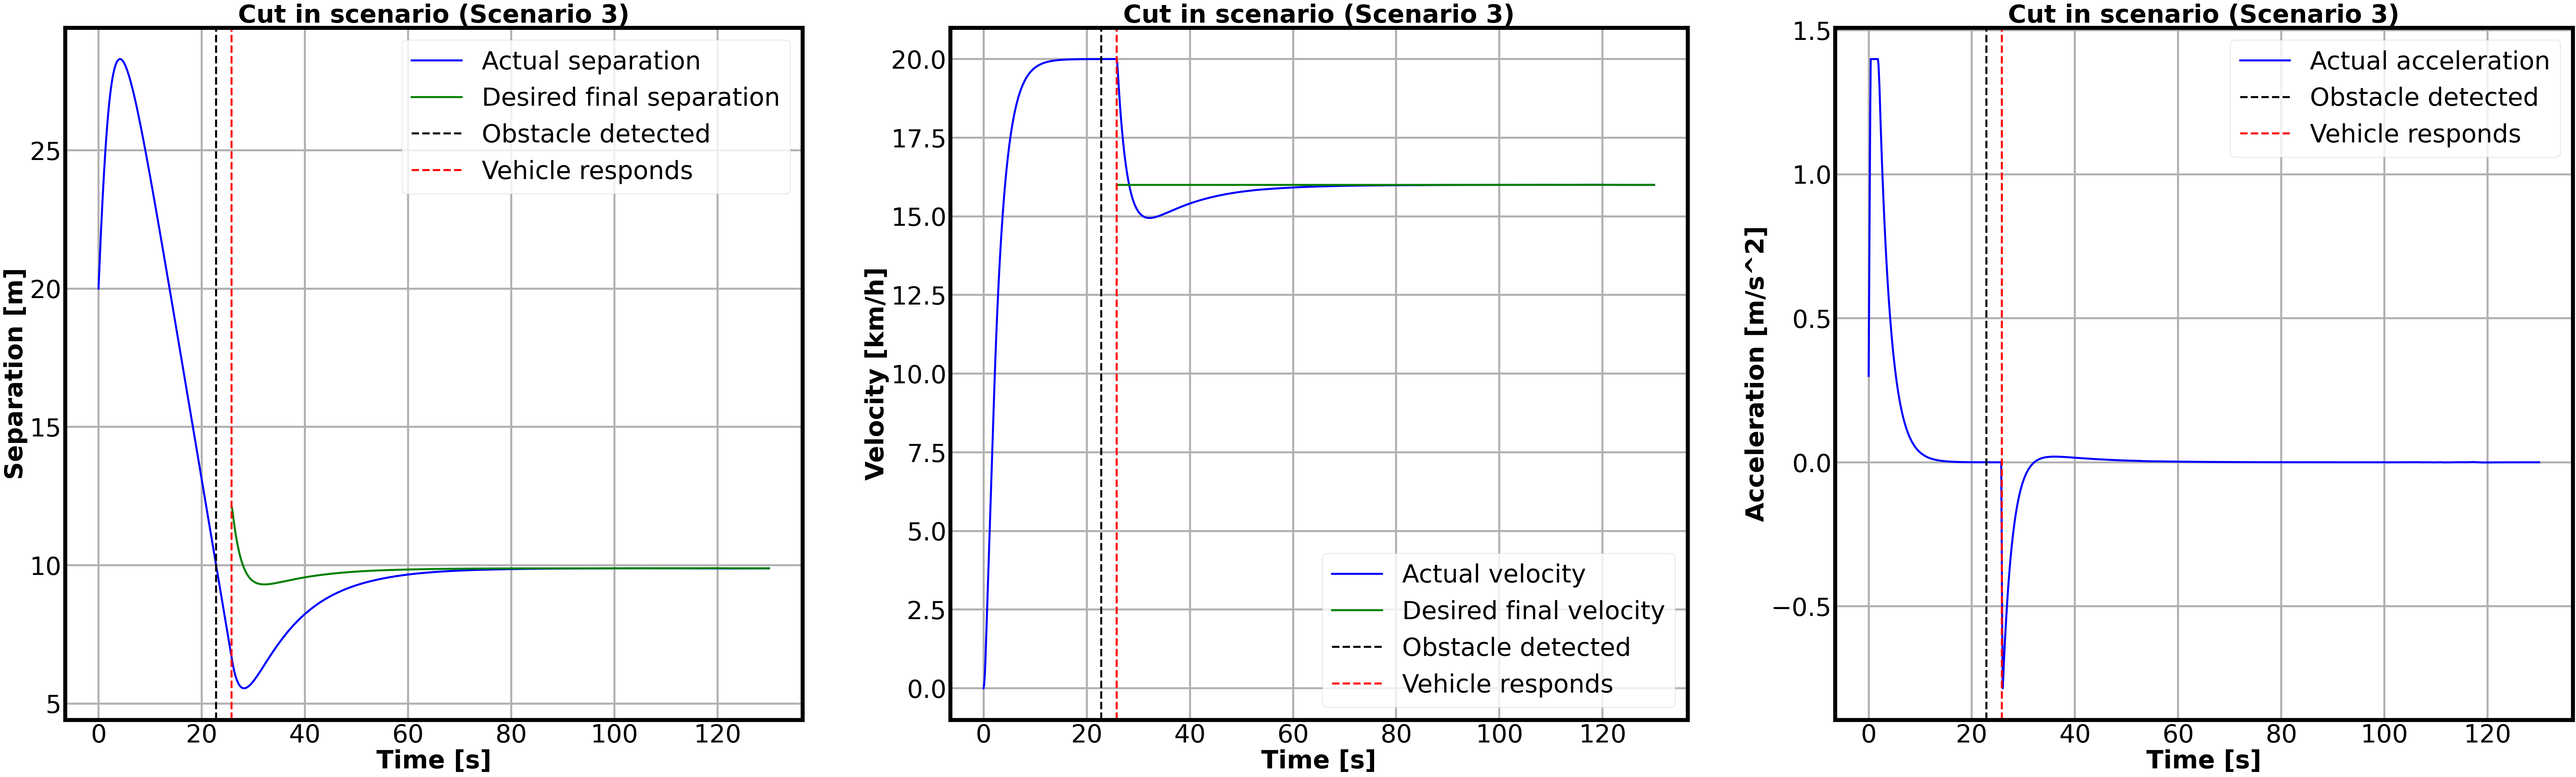

Plot: Cut in scenario (Scenario 3)
Separation -> min: 5.55, final: 9.88
Velocity   -> max: 20.00, final: 16.00
Acceleration -> min: -0.78, max: 1.40, final: 0.00


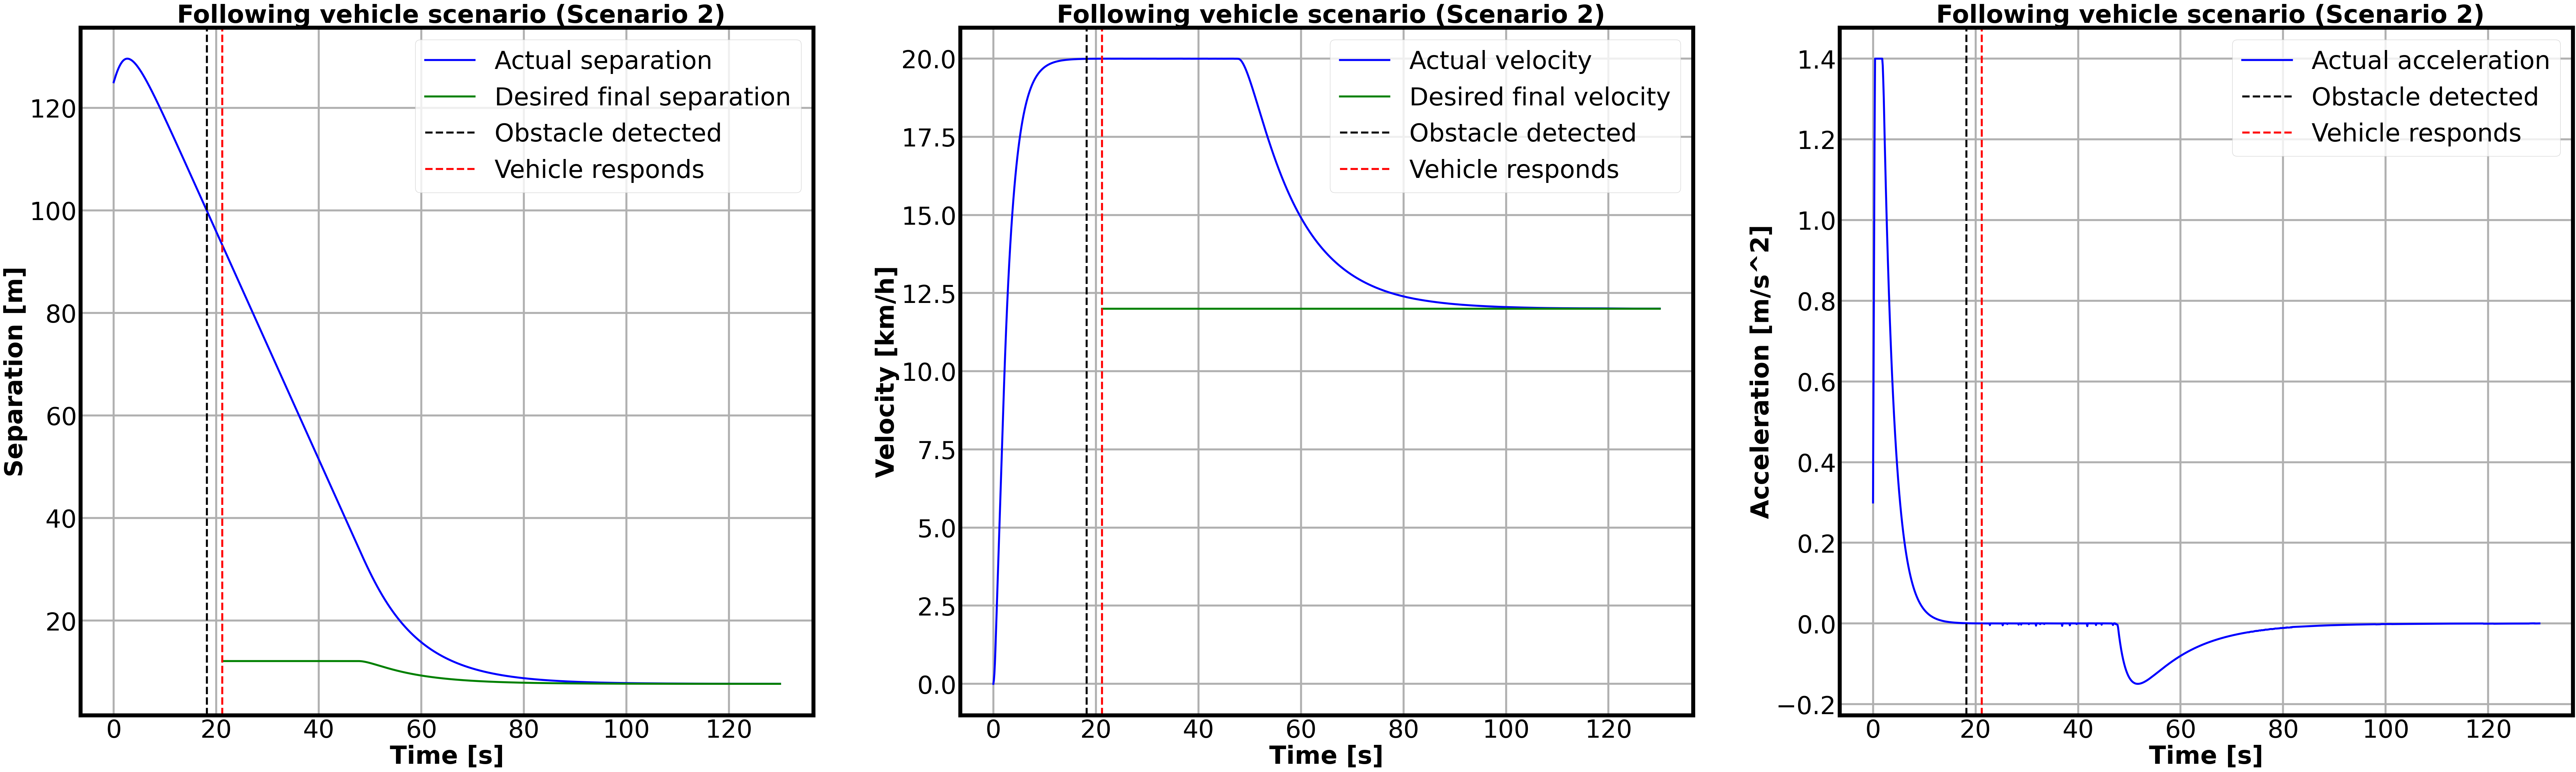

Plot:  Following vehicle scenario (Scenario 2)
Separation -> min: 7.67, final: 7.67
Velocity   -> max: 20.00, final: 12.00
Acceleration -> min: -0.15, max: 1.40, final: 0.00


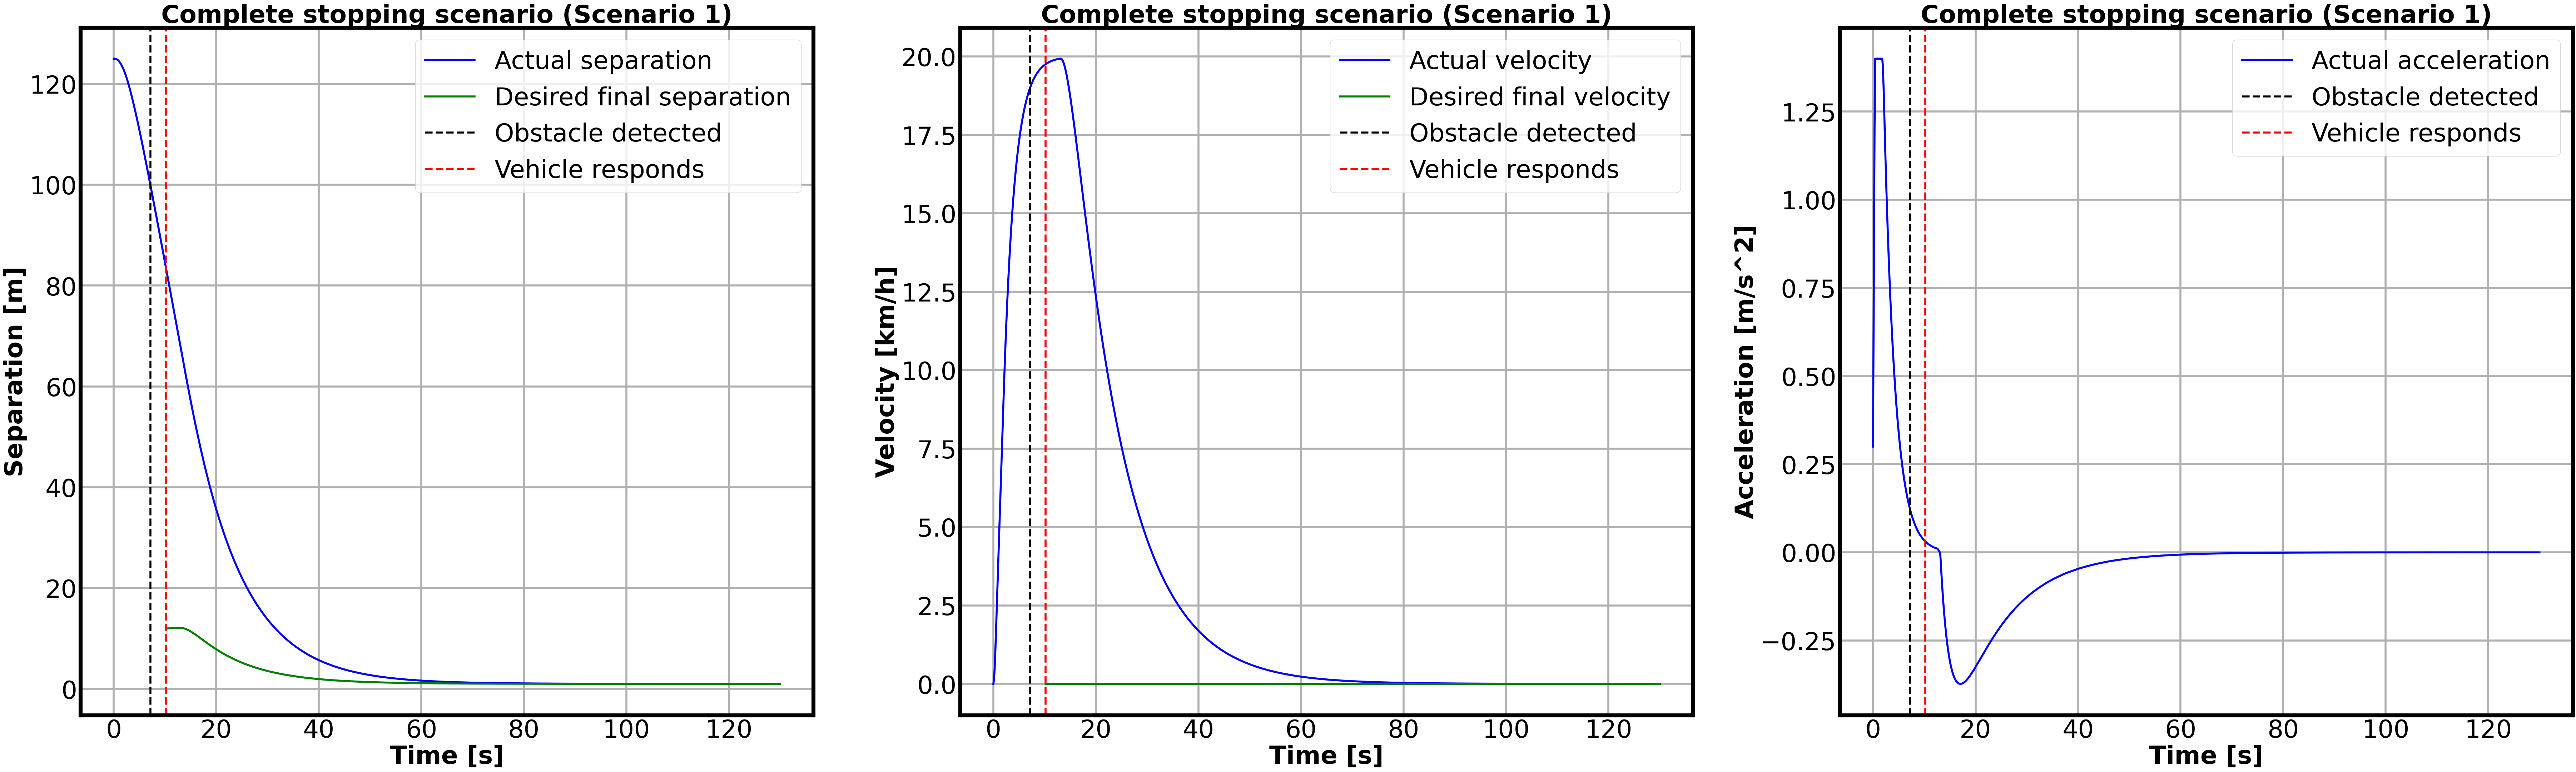

Plot: Complete stopping scenario (Scenario 1)
Separation -> min: 1.00, final: 1.00
Velocity   -> max: 19.93, final: 0.00
Acceleration -> min: -0.37, max: 1.40, final: -0.00


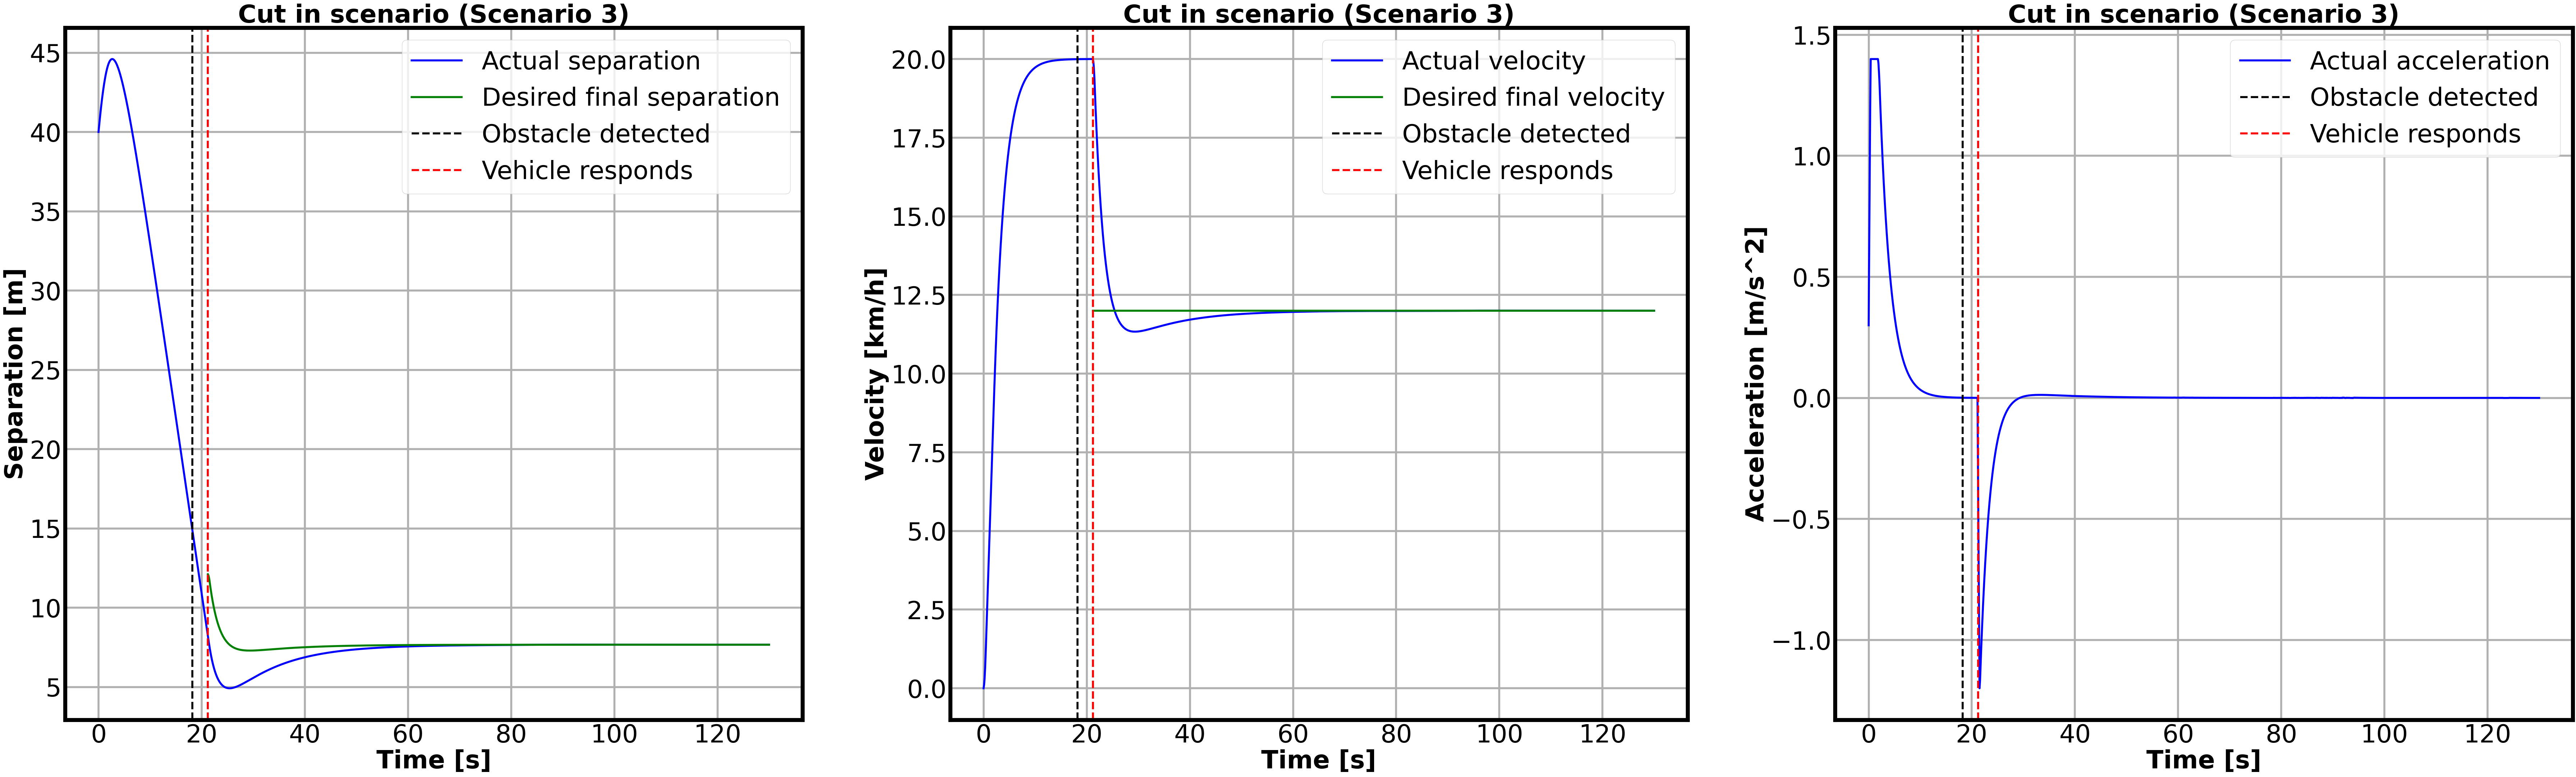

Plot: Cut in scenario (Scenario 3)
Separation -> min: 4.92, final: 7.67
Velocity   -> max: 20.00, final: 12.00
Acceleration -> min: -1.20, max: 1.40, final: -0.00


In [6]:
for i in range(len(store_times)):
    plot([store_times[i]], [store_accelerations[i]], [store_velocities[i]], [store_separations[i]], store_detected_times[i], store_start_reaction_times[i], CP.Drs[i], CP.Vps[i], titles[i])

In [7]:
folder_path = os.path.join(internal_WSM_dir, 'store_results_data')
times_file_path = os.path.join(folder_path, 'times.pkl')
separations_file_path = os.path.join(folder_path, 'separations.pkl')
velocities_file_path = os.path.join(folder_path, 'velocities.pkl')
accelerations_file_path = os.path.join(folder_path, 'accelerations.pkl')
detected_times_file_path = os.path.join(folder_path, 'detected_times.pkl')
start_reaction_times_file_path = os.path.join(folder_path, 'start_reaction_times.pkl')

with open(times_file_path, 'wb') as f:
    pickle.dump(store_times, f)
    
with open(separations_file_path, 'wb') as f:
    pickle.dump(store_separations, f)

with open(velocities_file_path, 'wb') as f:
    pickle.dump(store_velocities, f)

with open(accelerations_file_path, 'wb') as f:
    pickle.dump(store_accelerations, f)

with open(detected_times_file_path, 'wb') as f:
    pickle.dump(store_detected_times, f)
    
with open(start_reaction_times_file_path, 'wb') as f:
    pickle.dump(store_start_reaction_times, f)

print(f"The required data has been saved at : {folder_path}")

The required data has been saved at : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\5_MPC_Controllers\1_Without_System_model\store_results_data
